<a href="https://colab.research.google.com/github/ariefpurnamamuharram/ariefpurnamamuharram.github.io/blob/master/files/W02_23521013_Arief_Purnama_Muharram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-2 Assignment: data_bmkg.csv
___
Name: Arief Purnama Muharram<br>
Student number: 23521013

In [ ]:
# Install all of the requirements.
!pip install pandas
!pip install numpy
!pip install scikit-learn 
!pip install imbalanced-learn

In [ ]:
# Connect the Google Colab with the Google Drive account
# so the Colab can access the Drive's contents.
from google.colab import drive 
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Set Pandas options.
pd.set_option('display.max_columns', None)

# Import the data.
# I place the data in the Google Drive's root folder.
df = pd.read_csv('/content/drive/MyDrive/data_bmkg.csv', delimiter=';', header=1)

# Print sample of the data.
print('[data_bmkg.csv]')
print(df.head(5))

print('\n')

# Print summary of the data.
print('[Data Summary]')
print(df.info())

[data_bmkg.csv]
  ID Stasiun              Nama Stasiun         Lat        Lng  Elevasi  \
0    STA2181  AWS Stamet 745 Kemayoran  -6.155.946  1.068.423      3.0   
1    STA2181  AWS Stamet 745 Kemayoran  -6.155.946  1.068.423      3.0   
2    STA2181  AWS Stamet 745 Kemayoran  -6.155.946  1.068.423      3.0   
3    STA2181  AWS Stamet 745 Kemayoran  -6.155.946  1.068.423      3.0   
4    STA2181  AWS Stamet 745 Kemayoran  -6.155.946  1.068.423      3.0   

            Tanggal   rr  ws_avg ws_max wd_avg  tt_air_max  tt_air_avg  \
0  01/03/2021 00:00  0.0     1.3    1.8    215        29.0        29.0   
1  01/03/2021 00:01  0.0     0.0    0.9      0        29.0        29.0   
2  01/03/2021 00:02  0.0     0.0    0.5      0        29.1        29.1   
3  01/03/2021 00:03  0.0     0.0      0      0        29.1        29.1   
4  01/03/2021 00:04  0.0     1.2    1.2    199        29.1        29.1   

   tt_air_min  rh_avg  pp_air sr_avg sr_max  nr  wl  tt_sea  tt_pan  ws_50cm  \
0        28.9 

## Data preprocessing
___

In [ ]:
# [Understanding the problem]
# The aim of this task is to identify whether the weather is normal or extreme.
# An extreme weather is determined by the following characteristics.
# - Air temperature: < 15 or > 35 degree Celcius
# - Rain rate: > 100 mm/day
# - Air humidity: < 40%
# - Wind speed: > 10,7 m/s

In [ ]:
# [Drop the unnecessary data attribute]
# In this case, we don't need all except data attribute that can distinguish
# between normal and extreme weather.

df = df.drop(['nr', 'wl', 'tt_sea', 'tt_pan', 'ws_50cm', 'wl_pan', 'ev_pan', 
         'konduktivitas', 'ph_sea', 'ID Stasiun', 'Nama Stasiun', 'Lat', 
         'Lng', 'Elevasi', 'Tanggal', 'ws_max', 'wd_avg', 'tt_air_max', 
         'tt_air_min', 'pp_air', 'sr_avg', 'sr_max'], axis=1, inplace=False)

# Print the data info.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rr          619 non-null    float64
 1   ws_avg      619 non-null    float64
 2   tt_air_avg  619 non-null    float64
 3   rh_avg      619 non-null    float64
dtypes: float64(4)
memory usage: 19.6 KB
None


In [ ]:
# [Clean the null data]
# If there is row containing any null data, clean it!

df = df.dropna(how='any', inplace=False)

# Print the data info.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 619 entries, 0 to 618
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rr          619 non-null    float64
 1   ws_avg      619 non-null    float64
 2   tt_air_avg  619 non-null    float64
 3   rh_avg      619 non-null    float64
dtypes: float64(4)
memory usage: 24.2 KB
None


In [ ]:
# [Is there any duplicated data?]
# Check the possibility of duplicate data on all rows.

total_duplicated_data = df.duplicated(keep='first').sum()

# Print the result.
print('There are ' + str(total_duplicated_data) + ' duplicated rows in the data!')

There are 37 duplicated rows in the data!


In [ ]:
# [Drop the duplicate data]

df.drop_duplicates(keep='first', inplace=True)

# Print the data info.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 582 entries, 0 to 618
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rr          582 non-null    float64
 1   ws_avg      582 non-null    float64
 2   tt_air_avg  582 non-null    float64
 3   rh_avg      582 non-null    float64
dtypes: float64(4)
memory usage: 22.7 KB
None


In [ ]:
# [Is the weather normal or extreme?]
# Determine whether the weather normal or extreme based on the determined
# criteria.

import numpy as np

df['conclusion'] = np.where((df['tt_air_avg'] < 15) | (df['tt_air_avg'] > 35) | (df['rr'] > 100) | (df['rh_avg'] < 40.0) | (df['ws_avg'] > 10.7), 'E', 'N')

print(df.groupby(['conclusion']).size())

conclusion
E    142
N    440
dtype: int64


## Data Visualization
___

In [ ]:
# [Generate descriptive statistics of the data]

df.describe()

,rr,ws_avg,tt_air_avg,rh_avg
count,582.000000,582.000000,582.000000,582.000000
mean,4.858419,48.688969,28.303746,77.578471
std,5.869941,92.635660,3.313055,18.786671
min,0.000000,0.000000,24.400000,49.700000
25%,0.000000,0.325000,25.300000,59.000000
50%,0.900000,1.600000,26.685000,90.050000
75%,10.950000,4.675000,31.700000,95.575000
max,16.000000,352.500000,34.800000,98.500000


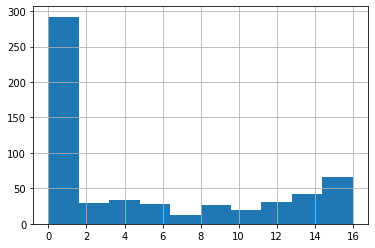

In [ ]:
# [Create histogram of rain rate data]

df['rr'].hist()

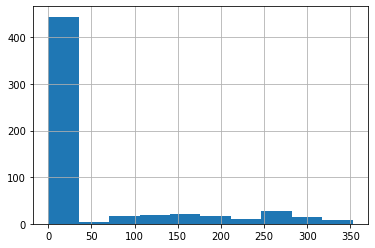

In [ ]:
# [Create histogram of wind speed (average) data]

df['ws_avg'].hist()

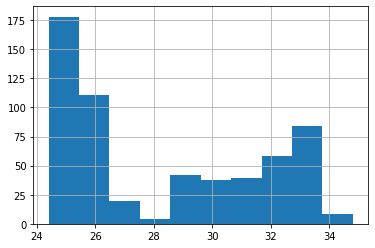

In [ ]:
# [Create histogram of air temperature (average) data]

df['tt_air_avg'].hist()

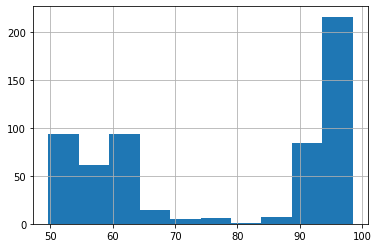

In [ ]:
# [Create histogram of air humidity (average) data]

df['rh_avg'].hist()

## Decision Tree
___

In [ ]:
# [Balancing the data]
# As mentioned above, tha normal and extreme weather data is imbalanced.
# For decision tree algorithm, I think it's better if the data is balance.
# So, I prefer to choose undersampling method to balance the data.

from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

X = df.drop(['conclusion'], axis=1, inplace=False)
y = df['conclusion']

rus = RandomUnderSampler(random_state=0)
X_resampled, y_resampled = rus.fit_resample(X, y)

print(sorted(Counter(y_resampled).items()))

[('E', 142), ('N', 142)]


In [ ]:
# [Create train and test dataset]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, 
                                                    test_size=0.25, 
                                                    random_state=0)

feature_names = X.columns

In [ ]:
# [Decision tree algorithm]

from sklearn import tree

dtree = tree.DecisionTreeClassifier()
dtree = dtree.fit(X_train, y_train)

# Print the tree
# tree.plot_tree(dtree, feature_names=feature_names, class_names=['E', 'N'], filled=True)

### Evaluation

In [ ]:
# [Confusion matrix]

from sklearn.metrics import confusion_matrix

y_pred = dtree.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Print the info
print("[Confusion Matrix]\n")
print(cm)

[Confusion Matrix]

[[30  0]
 [ 0 41]]


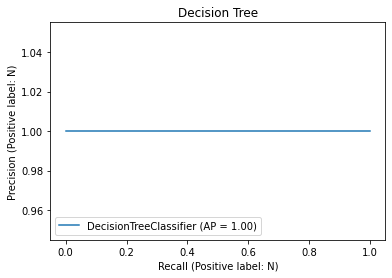

In [ ]:
# [Precision and recall]

from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    dtree, X_test, y_test
)

_ = display.ax_.set_title("Decision Tree")

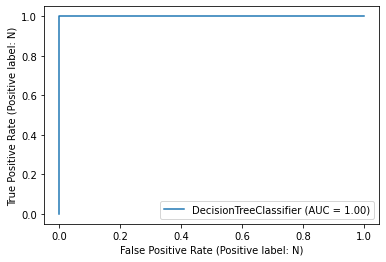

In [ ]:
# [ROC and AUC]

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(dtree, X_test, y_test)

## Support Vector Machines (SVM)
____

In [ ]:
# [Create train and test dataset]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, 
                                                    random_state=0)

feature_names = X.columns

In [ ]:
# [SVM algorithm]

from sklearn import svm

svc = svm.SVC(kernel='linear', decision_function_shape='ovo')
svc = svc.fit(X_train, y_train)

### Evaluation

In [ ]:
# [Confusion matrix]

from sklearn.metrics import confusion_matrix

y_pred = svc.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Print the info.
print("[Confusion Matrix]\n")
print(cm)

[Confusion Matrix]

[[ 37   0]
 [  0 109]]


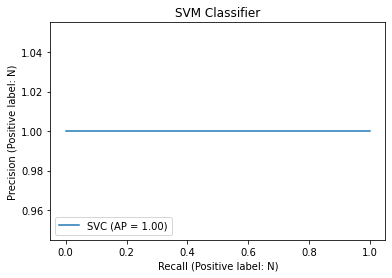

In [ ]:
# [Precision and recall]

from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    svc, X_test, y_test
)

_ = display.ax_.set_title("SVM Classifier")

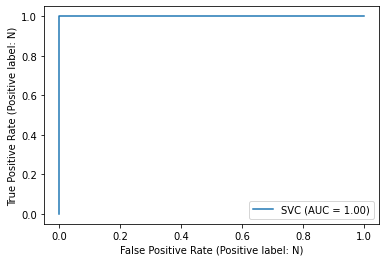

In [ ]:
# [ROC and AUC]

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(svc, X_test, y_test)